In [22]:
import osmnx as ox
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random, time, warnings
warnings.filterwarnings('ignore')

# ── 1. Download road network ──────────────────────────────────────
city = "Linz, Austria"
print("Downloading road network...")
G = ox.graph_from_place(city, network_type='drive')
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)
print(f"Graph: {len(G.nodes)} nodes, {len(G.edges)} edges")

# ── 2. Fetch ALL restaurants ──────────────────────────────────────
print("Fetching restaurants...")
tags = {"amenity": "restaurant"}
restaurants = ox.features.features_from_place(city, tags)

# Keep only Point or centroid-able geometries
restaurants = restaurants.copy()
restaurants['lat'] = restaurants.geometry.centroid.y
restaurants['lon'] = restaurants.geometry.centroid.x

# Drop duplicates and NaNs
restaurants = restaurants[['lat', 'lon', 'name']].dropna(subset=['lat', 'lon'])
restaurants = restaurants.drop_duplicates(subset=['lat', 'lon']).reset_index(drop=True)
print(f"Restaurants found: {len(restaurants)}")
restaurants = restaurants.head(150).reset_index(drop=True)
print(f"Using {len(restaurants)} restaurants")
# ── 3. Snap to nearest graph nodes ───────────────────────────────
print("Snapping to road network nodes...")
restaurants['node'] = restaurants.apply(
    lambda r: ox.distance.nearest_nodes(G, X=r['lon'], Y=r['lat']), axis=1
)

# Drop restaurants that snap to the same node
restaurants = restaurants.drop_duplicates(subset=['node']).reset_index(drop=True)
print(f"Unique snapped restaurants: {len(restaurants)}")

# ── 4. Assign time windows ────────────────────────────────────────
# Times in minutes from 00:00
# Each restaurant randomly gets lunch, dinner, or all-day window
random.seed(42)
def random_time_window():
    kind = random.choices(['lunch', 'dinner', 'allday'], weights=[0.3, 0.3, 0.4])[0]
    if kind == 'lunch':   return (660, 840)   # 11:00 – 14:00
    if kind == 'dinner':  return (1080, 1320) # 18:00 – 22:00
    return (660, 1320)                         # 11:00 – 22:00

restaurants['tw_open']  = [random_time_window()[0] for _ in range(len(restaurants))]
restaurants['tw_close'] = [random_time_window()[1] for _ in range(len(restaurants))]
# Fix: ensure close > open
restaurants['tw_close'] = restaurants.apply(
    lambda r: r['tw_close'] if r['tw_close'] > r['tw_open'] else r['tw_open'] + 120, axis=1
)
restaurants['service_time'] = 30  # minutes spent at each restaurant

print("\nSample restaurants:")
print(restaurants[['name','lat','lon','tw_open','tw_close']].head(10).to_string())
print(f"\nTotal stops to visit: {len(restaurants)}")

Graph: 3475 nodes, 8219 edges
Fetching restaurants...
Restaurants found: 316
Using 150 restaurants
Snapping to road network nodes...
Unique snapped restaurants: 126

Sample restaurants:
                     name        lat        lon  tw_open  tw_close
0         Stadtbräu Josef  48.299706  14.291311      660       840
1              Golden Pub  48.312988  14.282716      660      1320
2    Pizzeria Monte Verde  48.313991  14.281167      660      1320
3              Bella Casa  48.334765  14.321172      660      1320
4  Ost18 Asian Restaurant  48.329202  14.320524      660      1320
5                    Oase  48.330183  14.324424      660       840
6          Pizzeria David  48.313179  14.286710      660      1320
7                   Hamta  48.313014  14.282010      660      1320
8            Fischerhäusl  48.308940  14.282304     1080      1200
9                 Izakaya  48.302943  14.283999      660      1320

Total stops to visit: 126


In [23]:
from joblib import Parallel, delayed

nodes     = restaurants['node'].tolist()
n         = len(nodes)
INF       = 999999

print(f"Computing {n}x{n} = {n*n:,} shortest paths on real road network...")
print("This may take 5–15 minutes depending on your machine.\n")

start = time.time()

def dijkstra_row(i):
    """Compute distances and travel times from node i to all other nodes."""
    try:
        lengths = nx.single_source_dijkstra_path_length(G, nodes[i], weight='length')
        times   = nx.single_source_dijkstra_path_length(G, nodes[i], weight='travel_time')
        dist_row = [lengths.get(nodes[j], INF) for j in range(n)]
        time_row = [times.get(nodes[j],   INF) for j in range(n)]
    except Exception:
        dist_row = [INF] * n
        time_row = [INF] * n
    return dist_row, time_row

# Parallel computation across rows
results = Parallel(n_jobs=-1, verbose=5)(delayed(dijkstra_row)(i) for i in range(n))

dist_matrix = np.array([r[0] for r in results], dtype=float)
time_matrix = np.array([r[1] for r in results], dtype=float)  # seconds

# Convert travel time to minutes
time_matrix_min = time_matrix / 60.0

elapsed = time.time() - start
print(f"\nDone in {elapsed/60:.1f} minutes")
print(f"Distance matrix: {dist_matrix.shape}, max={dist_matrix.max()/1000:.1f} km")
print(f"Time matrix:     {time_matrix_min.shape}, max={time_matrix_min.max():.1f} min")

# Save matrices
np.save("linz_dist_matrix.npy",      dist_matrix)
np.save("linz_time_matrix_min.npy",  time_matrix_min)
restaurants.to_csv("linz_restaurants_tw.csv", index=False)
print("Saved matrices and restaurant data.")

Computing 126x126 = 15,876 shortest paths on real road network...
This may take 5–15 minutes depending on your machine.



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    8.3s



Done in 0.4 minutes
Distance matrix: (126, 126), max=1000.0 km
Time matrix:     (126, 126), max=16666.7 min
Saved matrices and restaurant data.


[Parallel(n_jobs=-1)]: Done 126 out of 126 | elapsed:   22.7s finished


Running GA: 126 stops, 4 salesmen, 2000 generations
Gen    0 | fit=1,728,938 | dist=1563.5km | penalty=165,433 | violations=57/126 | t=0s
Gen   10 | fit=1,595,429 | dist=1537.6km | penalty=57,819 | violations=35/126 | t=0s
Gen   20 | fit=1,534,517 | dist=1481.9km | penalty=52,654 | violations=32/126 | t=1s
Gen   30 | fit=1,494,756 | dist=1447.9km | penalty=46,899 | violations=30/126 | t=1s
Gen   40 | fit=1,467,408 | dist=1418.0km | penalty=49,382 | violations=31/126 | t=2s
Gen   50 | fit=1,436,343 | dist=1393.7km | penalty=42,662 | violations=26/126 | t=2s
Gen   60 | fit=1,416,638 | dist=1384.0km | penalty=32,650 | violations=25/126 | t=2s
Gen   70 | fit=1,402,982 | dist=1372.8km | penalty=30,177 | violations=21/126 | t=3s
Gen   80 | fit=1,398,313 | dist=1368.0km | penalty=30,280 | violations=19/126 | t=3s
Gen   90 | fit=1,389,726 | dist=1365.6km | penalty=24,144 | violations=16/126 | t=3s
Gen  100 | fit=1,384,564 | dist=1363.8km | penalty=20,777 | violations=13/126 | t=4s
Gen  110 | f

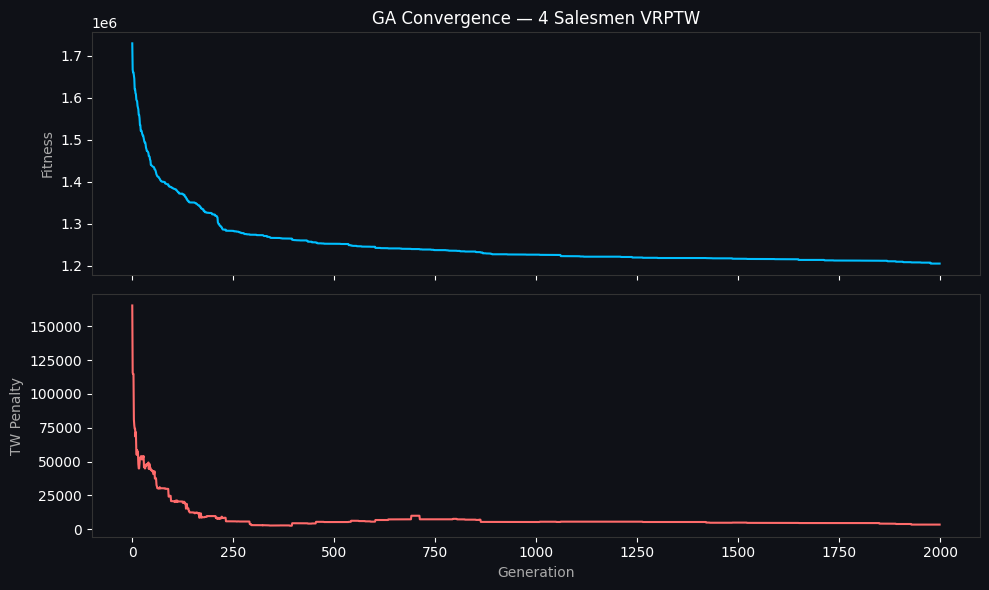

In [29]:
# ── Config ────────────────────────────────────────────────────────
N_SALESMEN        = 4
START_TIME        = 600.0    # 10:00
PENALTY_PER_MIN   = 10.0
INF               = 999999.0

n            = len(restaurants)
tw_open      = restaurants['tw_open'].values.astype(float)
tw_close     = restaurants['tw_close'].values.astype(float)
service_time = restaurants['service_time'].values.astype(float)

# ── Widen time windows ────────────────────────────────────────────
random.seed(42)
def random_time_window():
    kind = random.choices(['lunch', 'dinner', 'allday'], weights=[0.25, 0.25, 0.5])[0]
    if kind == 'lunch':   return (600, 900)    # 10:00 – 15:00  (wider)
    if kind == 'dinner':  return (1020, 1380)  # 17:00 – 23:00  (wider)
    return (600, 1380)                          # 10:00 – 23:00

restaurants['tw_open']  = [random_time_window()[0] for _ in range(n)]
restaurants['tw_close'] = [random_time_window()[1] for _ in range(n)]
restaurants['tw_close'] = restaurants.apply(
    lambda r: r['tw_close'] if r['tw_close'] > r['tw_open'] else r['tw_open'] + 180, axis=1
)
restaurants['service_time'] = 20  # slightly faster service

tw_open      = restaurants['tw_open'].values.astype(float)
tw_close     = restaurants['tw_close'].values.astype(float)
service_time = restaurants['service_time'].values.astype(float)

# ── Chromosome: flat list of n stops, split into N_SALESMEN routes ─
# We encode the split points as the first N_SALESMEN-1 cut positions
# Chromosome = permutation of 0..n-1  (split evenly to start)

def split_route(chromosome):
    """Split flat chromosome into N_SALESMEN sub-routes as evenly as possible."""
    size    = n // N_SALESMEN
    routes  = []
    for s in range(N_SALESMEN):
        start = s * size
        end   = (s + 1) * size if s < N_SALESMEN - 1 else n
        routes.append(chromosome[start:end])
    return routes

def evaluate_multi(chromosome):
    routes       = split_route(chromosome)
    total_dist   = 0.0
    total_penalty= 0.0
    all_arrivals = {}  # stop_idx -> arrival time

    for route in routes:
        if not route:
            continue
        current_time = START_TIME
        for step, idx in enumerate(route):
            if step > 0:
                travel = time_matrix_min[route[step-1]][idx]
                current_time += travel
                total_dist   += dist_matrix[route[step-1]][idx]

            all_arrivals[idx] = current_time

            if current_time < tw_open[idx]:
                current_time = tw_open[idx]
            elif current_time > tw_close[idx]:
                total_penalty += (current_time - tw_close[idx]) * PENALTY_PER_MIN

            current_time += service_time[idx]

        # Return to depot (index 0 as virtual depot = first restaurant)
        total_dist += dist_matrix[route[-1]][route[0]]

    fitness = total_dist + total_penalty
    return fitness, total_dist, total_penalty, all_arrivals, routes

# ── GA operators ──────────────────────────────────────────────────
POP_SIZE       = 150
GENERATIONS    = 2000
ELITE_SIZE     = 15
MUTATION_RATE  = 0.03
TOURNAMENT_K   = 5
SNAPSHOT_EVERY = 10

def initial_population(pop_size):
    base = list(range(n))
    return [random.sample(base, n) for _ in range(pop_size)]

def tournament_select(population, fitnesses):
    contestants = random.sample(list(zip(population, fitnesses)), TOURNAMENT_K)
    return min(contestants, key=lambda x: x[1])[0]

def ordered_crossover(p1, p2):
    a, b = sorted(random.sample(range(n), 2))
    child = [None] * n
    child[a:b] = p1[a:b]
    fill = [x for x in p2 if x not in child]
    idx = 0
    for i in range(n):
        if child[i] is None:
            child[i] = fill[idx]; idx += 1
    return child

def mutate(route):
    route = route[:]
    for _ in range(3):
        if random.random() < MUTATION_RATE:
            op = random.choice(['swap', 'reverse', 'insert'])
            i, j = sorted(random.sample(range(n), 2))
            if op == 'swap':
                route[i], route[j] = route[j], route[i]
            elif op == 'reverse':
                route[i:j] = route[i:j][::-1]
            elif op == 'insert':
                city = route.pop(i)
                route.insert(j, city)
    return route

def two_opt_multi(chromosome, max_iter=30):
    best     = chromosome[:]
    best_fit = evaluate_multi(best)[0]
    for _ in range(max_iter):
        improved = False
        for i in range(1, n - 1):
            for j in range(i + 1, n):
                new     = best[:i] + best[i:j+1][::-1] + best[j+1:]
                new_fit = evaluate_multi(new)[0]
                if new_fit < best_fit:
                    best, best_fit = new, new_fit
                    improved = True
        if not improved:
            break
    return best

# ── Main GA loop ──────────────────────────────────────────────────
random.seed(42)
population   = initial_population(POP_SIZE)
best_chromo  = None
best_fit     = float('inf')
history_fit  = []
history_pen  = []
snapshots    = []

print(f"Running GA: {n} stops, {N_SALESMEN} salesmen, {GENERATIONS} generations")
t0 = time.time()

for gen in range(GENERATIONS):
    evals     = [evaluate_multi(c) for c in population]
    fitnesses = [e[0] for e in evals]

    best_idx = int(np.argmin(fitnesses))
    if fitnesses[best_idx] < best_fit:
        best_fit      = fitnesses[best_idx]
        best_chromo   = population[best_idx][:]
        best_eval     = evals[best_idx]

    history_fit.append(best_fit)
    history_pen.append(best_eval[2])

    if gen % SNAPSHOT_EVERY == 0:
        fit, d, p, arr, routes = evaluate_multi(best_chromo)
        snapshots.append((gen, best_chromo[:], fit, d, p, arr, routes))
        violations = sum(1 for idx, t in arr.items() if t > tw_close[idx])
        print(f"Gen {gen:4d} | fit={fit:,.0f} | dist={d/1000:.1f}km | "
              f"penalty={p:,.0f} | violations={violations}/{n} | "
              f"t={time.time()-t0:.0f}s")

    elite   = [population[i] for i in np.argsort(fitnesses)[:ELITE_SIZE]]
    new_pop = elite[:]
    while len(new_pop) < POP_SIZE:
        p1    = tournament_select(population, fitnesses)
        p2    = tournament_select(population, fitnesses)
        child = ordered_crossover(p1, p2)
        child = mutate(child)
        new_pop.append(child)
    population = new_pop

print(f"\nGA done in {(time.time()-t0)/60:.1f} min")
print("Running 2-opt polish...")
best_chromo = two_opt_multi(best_chromo)
fit, d, p, arr, routes = evaluate_multi(best_chromo)
snapshots.append((GENERATIONS, best_chromo[:], fit, d, p, arr, routes))
violations = sum(1 for idx, t in arr.items() if t > tw_close[idx])
print(f"\nFinal: {d/1000:.1f} km | penalty={p:,.0f} | violations={violations}/{n}")

# ── Convergence plot ──────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
fig.patch.set_facecolor('#0f1117')
for ax in (ax1, ax2):
    ax.set_facecolor('#0f1117')
    ax.tick_params(colors='white')
    for s in ax.spines.values(): s.set_edgecolor('#333')

ax1.plot(history_fit, color='#00bfff', linewidth=1.5)
ax1.set_ylabel('Fitness', color='#aaa')
ax1.set_title(f'GA Convergence — {N_SALESMEN} Salesmen VRPTW', color='white', fontsize=12)

ax2.plot(history_pen, color='#ff6b6b', linewidth=1.5)
ax2.set_ylabel('TW Penalty', color='#aaa')
ax2.set_xlabel('Generation', color='#aaa')

plt.tight_layout()
plt.show()

In [31]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection

# ── Salesman colors ───────────────────────────────────────────────
SALESMAN_COLORS   = ['#00bfff', '#ff6b6b', '#90ee90', '#ffaa00']
SALESMAN_LABELS   = ['Salesman A', 'Salesman B', 'Salesman C', 'Salesman D']

lats = restaurants['lat'].values
lons = restaurants['lon'].values

# ── Pre-compute road geometry for final routes ─────────────────────
print("Pre-computing road geometries for final routes...")
_, _, _, _, final_routes = evaluate_multi(snapshots[-1][1])

road_segments = {}  # (salesman_idx, step) -> [(lon, lat), ...]
for s_idx, route in enumerate(final_routes):
    full = route + [route[0]]
    for step in range(len(full) - 1):
        u_node = restaurants['node'].iloc[full[step]]
        v_node = restaurants['node'].iloc[full[step + 1]]
        try:
            path_nodes = nx.shortest_path(G, u_node, v_node, weight='travel_time')
            coords = []
            for a, b in zip(path_nodes[:-1], path_nodes[1:]):
                ed = G.get_edge_data(a, b, 0) or {}
                geom = ed.get('geometry', None)
                if geom:
                    coords += list(geom.coords)
                else:
                    coords += [(G.nodes[a]['x'], G.nodes[a]['y']),
                               (G.nodes[b]['x'], G.nodes[b]['y'])]
            road_segments[(s_idx, step)] = coords
        except Exception:
            road_segments[(s_idx, step)] = [
                (lons[full[step]], lats[full[step]]),
                (lons[full[step+1]], lats[full[step+1]])
            ]
    if s_idx == 0:
        print(f"  Salesman A: {len(route)} stops")
    elif s_idx == 1:
        print(f"  Salesman B: {len(route)} stops")
    else:
        print(f"  Salesman C: {len(route)} stops")
print("Done.")

# ── Build frames ───────────────────────────────────────────────────
HOLD_FRAMES    = 20
SHOWCASE_EVERY = max(1, len(snapshots) // 8)
showcase = snapshots[::SHOWCASE_EVERY] + [snapshots[-1]]

frames = []
for snap in showcase:
    gen, chromo, fit, dist, penalty, arrivals, routes = snap
    is_final = (gen == snapshots[-1][0])
    full_routes = [r + [r[0]] for r in routes]
    max_steps   = max(len(r) for r in full_routes)

    # Animate step by step — all salesmen move simultaneously
    for step in range(1, max_steps + 1):
        visited_per = [r[:step] for r in full_routes]
        frames.append({
            "gen":        gen,
            "dist":       dist,
            "penalty":    penalty,
            "visited":    visited_per,
            "full":       full_routes,
            "arrivals":   arrivals,
            "is_final":   is_final,
            "use_roads":  is_final,
            "routes":     routes,
        })

    for _ in range(HOLD_FRAMES):
        frames.append({
            "gen":        gen,
            "dist":       dist,
            "penalty":    penalty,
            "visited":    full_routes,
            "full":       full_routes,
            "arrivals":   arrivals,
            "is_final":   is_final,
            "use_roads":  is_final,
            "routes":     routes,
        })

print(f"Total frames: {len(frames)}")

# ── Figure ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 8))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')
ax.tick_params(colors='white', labelsize=7)
for spine in ax.spines.values():
    spine.set_edgecolor('#222')

margin = 0.008
ax.set_xlim(lons.min() - margin, lons.max() + margin)
ax.set_ylim(lats.min() - margin, lats.max() + margin)
ax.set_xlabel("Longitude", color='#666', fontsize=7)
ax.set_ylabel("Latitude",  color='#666', fontsize=7)

ox.plot_graph(G, ax=ax, show=False, close=False,
              node_size=0, edge_color='#1a2030',
              edge_linewidth=0.4, edge_alpha=0.5,
              bgcolor='#0f1117')

# Static restaurant dots colored by time window
def tw_color(i):
    o, c = tw_open[i], tw_close[i]
    if o >= 600  and c <= 900:  return '#ffaa00'
    if o >= 1020:               return '#aa44ff'
    return '#00cc88'

ax.scatter(lons, lats, c=[tw_color(i) for i in range(n)],
           s=35, zorder=5, alpha=0.6)

# Per-salesman dynamic elements
road_cols     = [LineCollection([], colors=SALESMAN_COLORS[s], linewidths=2.0,
                                alpha=0.85, zorder=6) for s in range(N_SALESMEN)]
straight_lines= [ax.plot([], [], '-',  color=SALESMAN_COLORS[s], lw=1.8,
                          alpha=0.8, zorder=6)[0] for s in range(N_SALESMEN)]
pending_lines = [ax.plot([], [], '--', color=SALESMAN_COLORS[s], lw=1.0,
                          alpha=0.3, zorder=4)[0] for s in range(N_SALESMEN)]
current_dots  = [ax.plot([], [], 'o',  color=SALESMAN_COLORS[s], ms=13,
                          zorder=9, markeredgecolor='white',
                          markeredgewidth=1)[0] for s in range(N_SALESMEN)]
for rc in road_cols:
    ax.add_collection(rc)

late_dots, = ax.plot([], [], 'x', color='#ff4444', ms=9, zorder=10, markeredgewidth=2)

title_text = ax.set_title('', color='white', fontsize=11, pad=10, fontweight='bold')
gen_text   = ax.text(0.02, 0.97, '', transform=ax.transAxes, color='white',
                     fontsize=9, va='top',
                     bbox=dict(facecolor='#0d1117', edgecolor='#444', boxstyle='round,pad=0.4'))
dist_text  = ax.text(0.98, 0.97, '', transform=ax.transAxes, color='#aaa',
                     fontsize=9, va='top', ha='right',
                     bbox=dict(facecolor='#0d1117', edgecolor='#444', boxstyle='round,pad=0.4'))
pen_text   = ax.text(0.98, 0.88, '', transform=ax.transAxes, color='#ff6b6b',
                     fontsize=9, va='top', ha='right',
                     bbox=dict(facecolor='#0d1117', edgecolor='#444', boxstyle='round,pad=0.4'))

legend_elements = [
    plt.Line2D([0],[0], color=SALESMAN_COLORS[s], lw=2, label=SALESMAN_LABELS[s])
    for s in range(N_SALESMEN)
] + [
    mpatches.Patch(color='#ffaa00', label='Lunch window'),
    mpatches.Patch(color='#aa44ff', label='Dinner window'),
    mpatches.Patch(color='#00cc88', label='All day'),
    plt.Line2D([0],[0], marker='x', color='#ff4444', label='TW violation',
               markersize=7, linestyle='None', markeredgewidth=2),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=7,
          facecolor='#0d1117', edgecolor='#444', labelcolor='white')

plt.tight_layout(pad=1.5)

# ── Update ────────────────────────────────────────────────────────
def update(fi):
    f         = frames[fi]
    use_roads = f["use_roads"]
    arrivals  = f["arrivals"]

    late_x, late_y = [], []

    for s in range(N_SALESMEN):
        visited  = f["visited"][s]
        full     = f["full"][s]
        step     = len(visited) - 1
        color    = SALESMAN_COLORS[s]

        # Pending
        pending_lines[s].set_data(
            [lons[full[i]] for i in range(max(0, step-1), len(full))],
            [lats[full[i]] for i in range(max(0, step-1), len(full))]
        )

        if use_roads:
            segs = []
            for st in range(min(step, len(full) - 1)):
                coords = road_segments.get((s, st), [])
                if len(coords) >= 2:
                    segs.append([(c[0], c[1]) for c in coords])
            road_cols[s].set_segments(segs)
            straight_lines[s].set_data([], [])
        else:
            road_cols[s].set_segments([])
            cx = [lons[visited[i]] for i in range(len(visited))]
            cy = [lats[visited[i]] for i in range(len(visited))]
            straight_lines[s].set_data(cx, cy)

        # Current dot
        current_dots[s].set_data([lons[visited[-1]]], [lats[visited[-1]]])

        # TW violations
        for st in range(min(step, len(arrivals))):
            idx = full[st]
            if idx in arrivals and arrivals[idx] > tw_close[idx]:
                late_x.append(lons[idx])
                late_y.append(lats[idx])

    late_dots.set_data(late_x, late_y)

    gen_lbl = "✓ Final (2-opt)" if f["is_final"] else f"Generation {f['gen']}"
    gen_text.set_text(gen_lbl)
    dist_text.set_text(f"{f['dist']/1000:.1f} km")
    pen_text.set_text(f"TW penalty: {f['penalty']:,.0f}")
    title_text.set_text(f"VRPTW — {N_SALESMEN} Salesmen on Real Roads")

    return (*road_cols, *straight_lines, *pending_lines,
            *current_dots, late_dots,
            gen_text, dist_text, pen_text, title_text)

ani = animation.FuncAnimation(
    fig, update,
    frames=len(frames),
    interval=250,
    blit=False
)

plt.close(fig)

output_path = "linz_vrptw_3salesmen.mp4"
ani.save(output_path, writer=animation.FFMpegWriter(fps=4, bitrate=2400), dpi=150)
print(f"Saved: {output_path}")

Pre-computing road geometries for final routes...
  Salesman A: 31 stops
  Salesman B: 31 stops
  Salesman C: 31 stops
  Salesman C: 33 stops
Done.
Total frames: 540
Saved: linz_vrptw_3salesmen.mp4
